## 1. Import Libraries and Load Insurance Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector


df = pd.read_csv('insurance.csv')
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## 2. Display Dataset Information and Summary Statistics

In [154]:
print(df.info())
print("\nSummary Statistics:")
print(df.describe())
print("\nNull values check:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

Summary Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.9125

## 3. How is age related to medical costs?

Correlation between age and charges:
              age   charges
age      1.000000  0.299008
charges  0.299008  1.000000


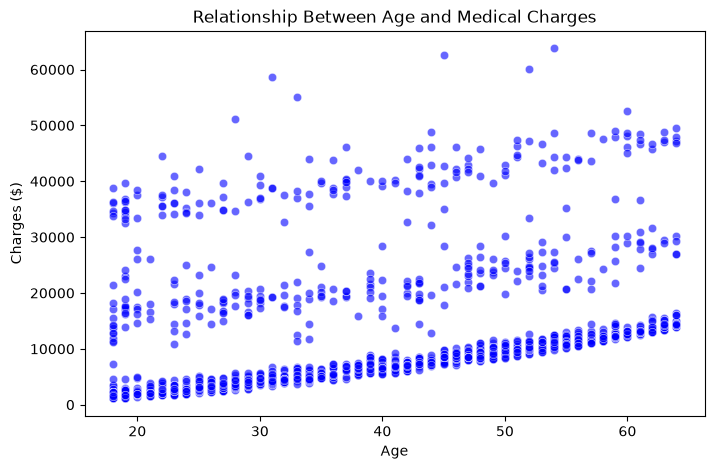

In [155]:
print("Correlation between age and charges:")
print(df[['age', 'charges']].corr())

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', alpha=0.6, color='b')
plt.title('Relationship Between Age and Medical Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.show()

**Explanation:** As people get older medical bills tend to go up you can actually see the costs cluster into three separate groups. Those who lived healthier lives probably would end up in the lower group.

## 4. How is number of children related to medical costs?

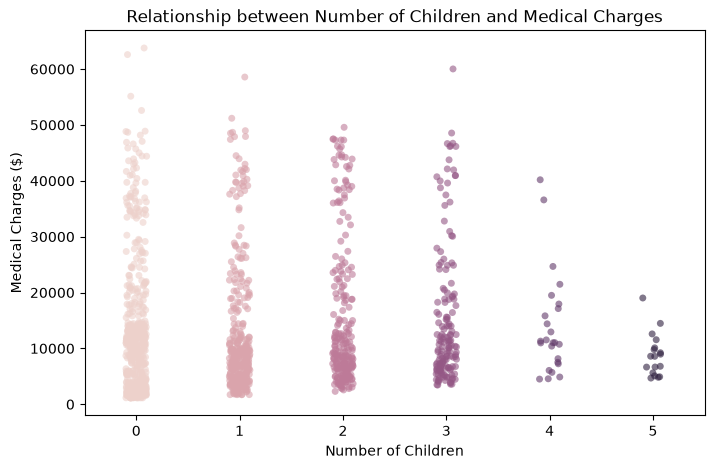

In [156]:
plt.figure(figsize=(8, 5))

sns.stripplot(
    data=df, 
    x='children', 
    y='charges', 
    hue='children', 
    legend=False, 
    alpha=0.6, 
    jitter=True
)

plt.title('Relationship between Number of Children and Medical Charges')
plt.xlabel('Number of Children')
plt.ylabel('Medical Charges ($)')
plt.show()

**Explanation:** People with 2 or 3 kids tend to have the highest charges while those with 5 kids have the lowest. Overall, the number of kids doesn't change much. 

## 5. How is the number of people distributed by region?

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


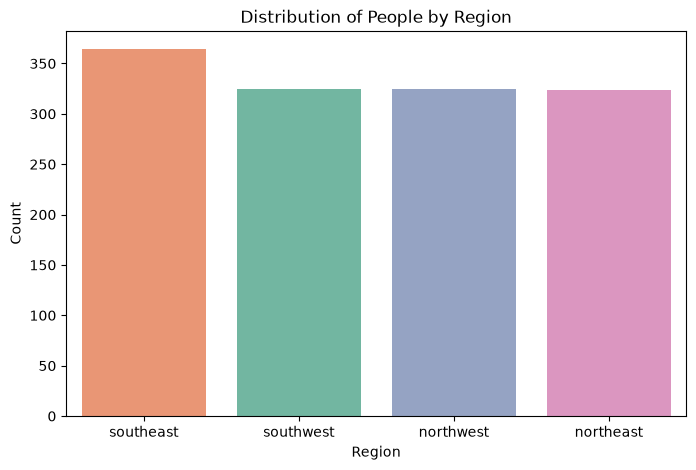

In [157]:
region_counts = df['region'].value_counts()
print(region_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='region', 
    order=region_counts.index, 
    palette='Set2', 
    hue='region', 
    legend=False
)
plt.title('Distribution of People by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

**Explanation:** The population distribution across regions is relatively even, with the southeast having a slightly higher representation (364 individuals), while northeast, northwest, and southwest each have around 324-325 individuals.

## 6. How is the number of people distributed by age?

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64


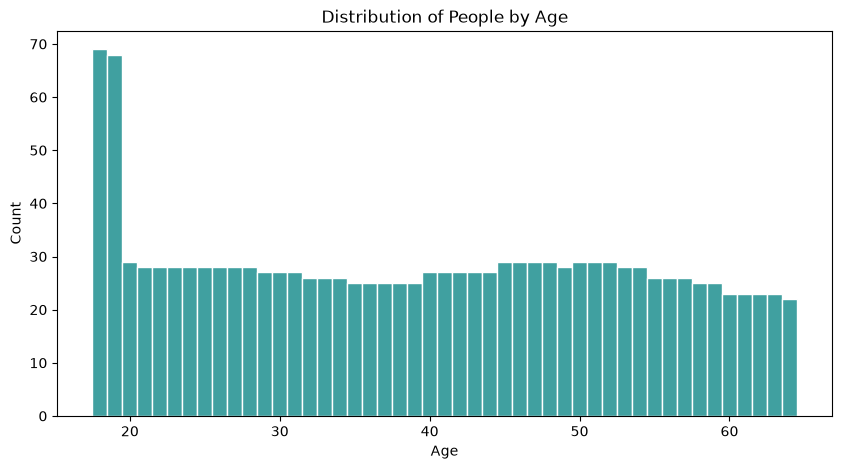

In [158]:
print(df['age'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(
    df['age'], 
    bins=range(int(df['age'].min()), int(df['age'].max()) + 2), 
    color='teal', 
    edgecolor='white',
    discrete=True
)
plt.title('Distribution of People by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Explanation:** The age distribution shows a high concentration of younger adults around 18-20 with a mostly even distribution from then on 20 - 65

## 7. How are the charges distributed?

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


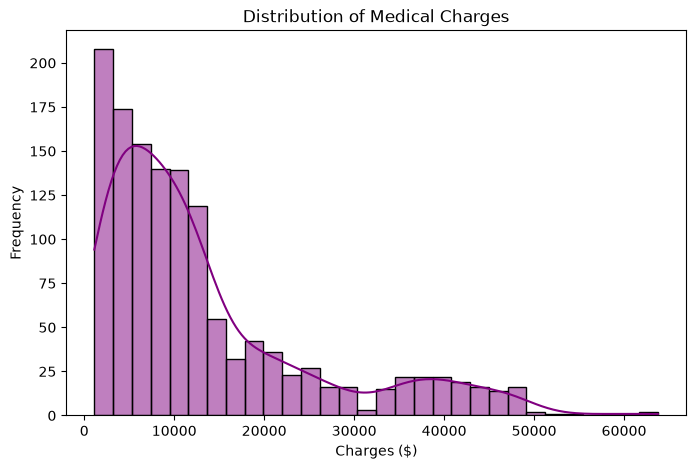

In [159]:
print(df['charges'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=30, kde=True, color='purple')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

**Explanation:** Most people have lower medical bills with a middle mark around $9k while a smaller group of people have really high costs that stretch all the way up to $60k.

## 8. Bin the BMI Column

bmi_category
Obese          707
Overweight     386
Normal         225
Underweight     20
Name: count, dtype: int64


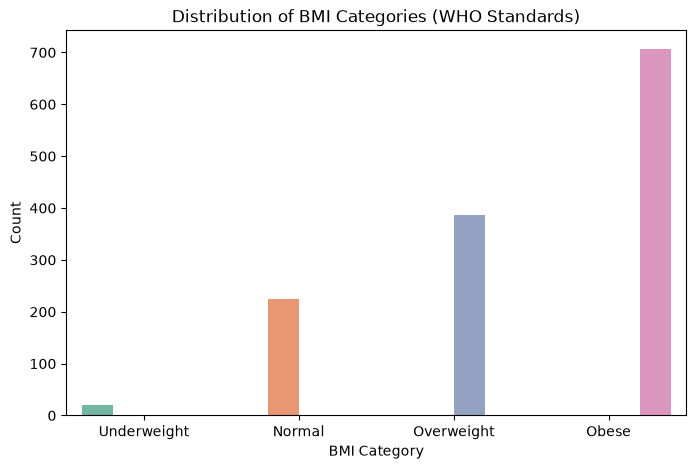

In [160]:

bins = [0, 18.5, 25, 30, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']


df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)

print(df['bmi_category'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='bmi_category', hue='bmi_category', order=labels, palette='Set2', legend=False)
plt.title('Distribution of BMI Categories (WHO Standards)')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

**Explanation:**  Most people in the dataset are either overweight or obese based on WHO standards, while only a fraction fewer fall into the normal or underweight categories.

## 9. How are the charges related to the BMI?

              bmi   charges
bmi      1.000000  0.198341
charges  0.198341  1.000000


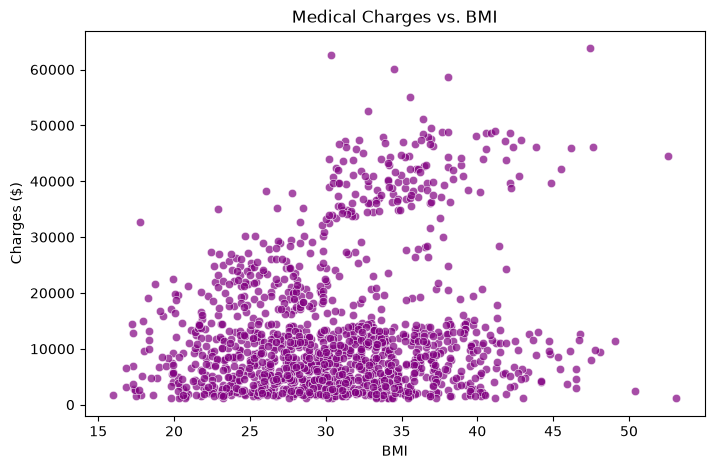

In [161]:
print(
    df[['bmi', 'charges']].corr()
)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.7, color='purple')
plt.title('Medical Charges vs. BMI')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.show()

**Explanation:** Medical costs tend to go up as BMI increases, and once people reach the overweight or obese range, you can clearly see a separate group of much higher charges start to appear.

## 10. How is the smoker status related to the charges?

  smoker       charges
0     no   8434.268298
1    yes  32050.231832


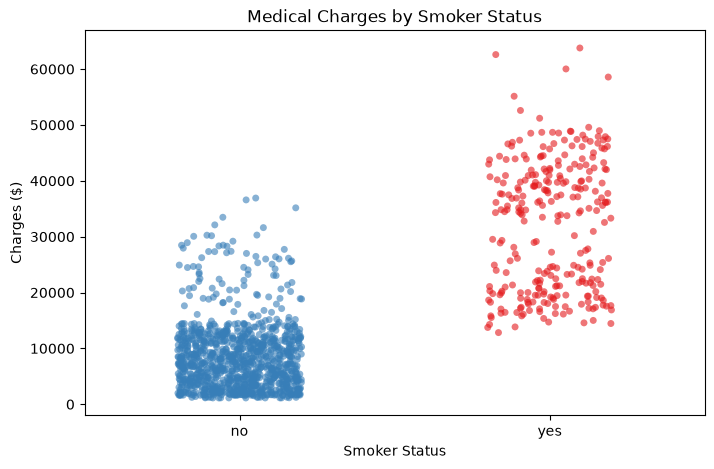

In [162]:
smoker_charges = df.groupby('smoker')['charges'].mean().reset_index()
print(smoker_charges)

plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x='smoker', y='charges', hue='smoker', order=['no', 'yes'], 
              palette='Set1', alpha=0.6, jitter=0.2, legend=False)
plt.title('Medical Charges by Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Charges ($)')
plt.show()

**Explanation:** Smoker status is one of the strongest determinants of medical costs. Smokers have an average charge of over $32k compared to just $8k for non smokers.

## 11. How are the charges related to the region?

      region       charges
0  northeast  13406.384516
1  northwest  12417.575374
2  southeast  14735.411438
3  southwest  12346.937377


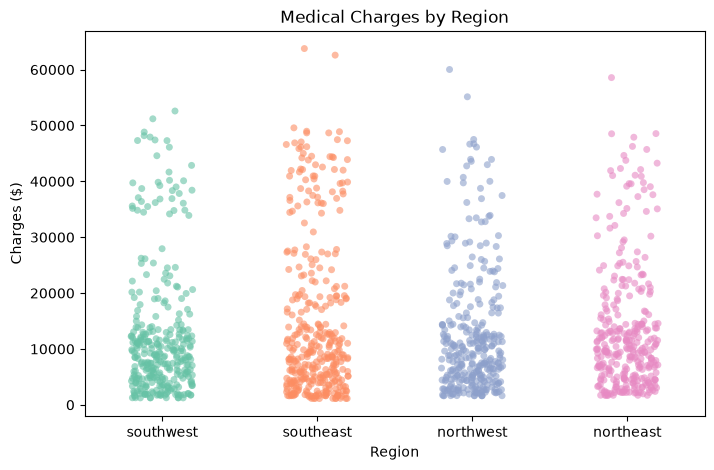

In [163]:
region_charges = df.groupby('region')['charges'].mean().reset_index()
print(region_charges)

plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x='region', y='charges', hue='region', palette='Set2', 
              alpha=0.6, jitter=0.2, legend=False)
plt.title('Medical Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges ($)')
plt.show()

**Explanation:** Medical charges tend to be somewhat equal between the southwest,northwest, and northeast regions, with the southeast having the slightly higher charges 

## 12. Which region has the highest obesity percentage?

      region  obesity_percentage
0  northeast           44.135802
1  northwest           45.538462
2  southeast           66.758242
3  southwest           53.230769


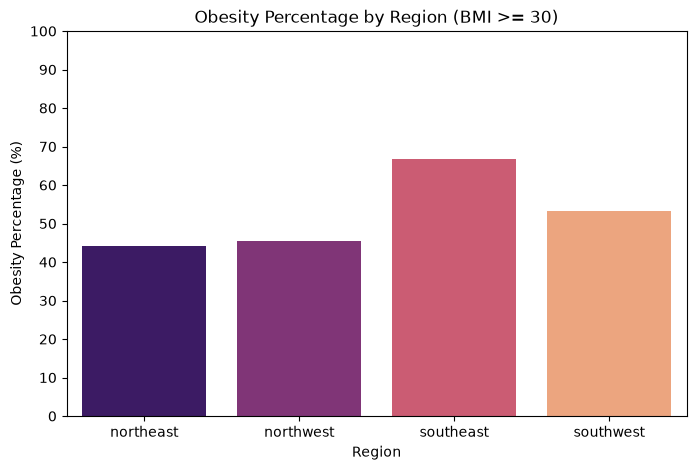

In [164]:
df['is_obese'] = df['bmi'] >= 30
obesity_percentage = (
    df.groupby('region')['is_obese'].mean() * 100
).reset_index()
obesity_percentage.columns = ['region', 'obesity_percentage']
print(obesity_percentage)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=obesity_percentage,
    x='region',
    y='obesity_percentage',
    hue='region',
    palette='magma',
    legend=False,
)
plt.title('Obesity Percentage by Region (BMI >= 30)')
plt.xlabel('Region')
plt.ylabel('Obesity Percentage (%)')
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))
plt.show()

**Explanation:** The southeast region has the highest obesity rate at about 65%, while the other regions range from 44% to 53%.

## 13. Create a simple regression to show the relationship between charges and age.

Coefficient:, 257.72


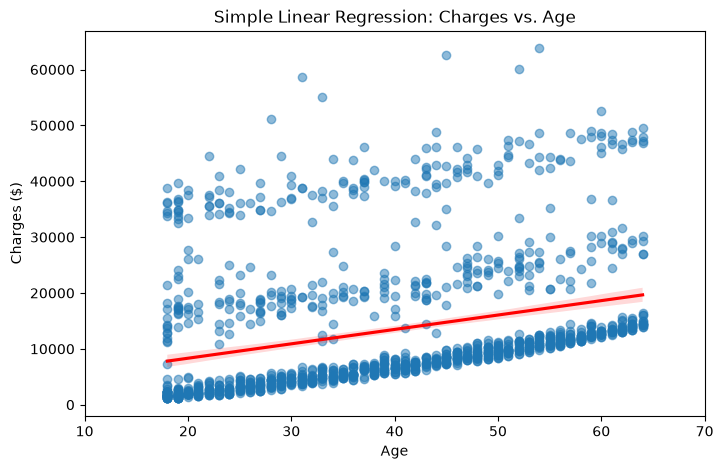

In [ ]:
X_simple = df[['age']]
y = df['charges']

reg_simple = LinearRegression()
reg_simple.fit(X_simple, y)
print(f"Coefficient: {reg_simple.coef_[0]:.2f}")

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='age',
    y='charges',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
)
plt.title('Simple Linear Regression: Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.xticks(range(10, 71, 10))
plt.show()

**Explanation:** The simple linear regression model shows that for every additional year of age, medical charges increase by approximately $257.72 on average slope = 257

## 14. How does this relationship change with smoking status?

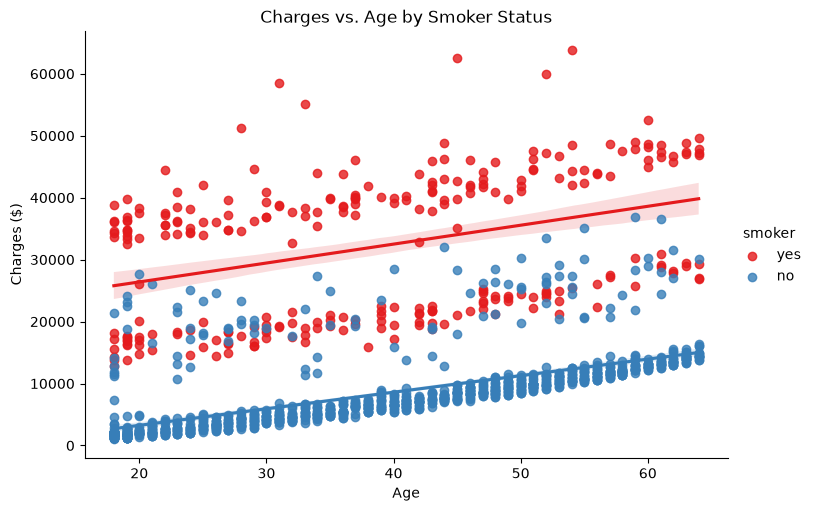

Smoker = yes  Slope = 305.24, Intercept= 20294.13
Smoker = no  Slope = 267.25, Intercept= -2091.42


In [166]:
sns.lmplot(data=df, x='age', y='charges', hue='smoker', height=5, aspect=1.5, palette='Set1')
plt.title('Charges vs. Age by Smoker Status')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.show()

for smoker_val in ['yes', 'no']:
    sub_df = df[df['smoker'] == smoker_val]
    model = LinearRegression().fit(sub_df[['age']], sub_df['charges'])
    print(f"Smoker = {smoker_val}  Slope = {model.coef_[0]:.2f}, Intercept= {model.intercept_:.2f}")

**Explanation:** Smokers start at a much higher baseline cost and see their medical bills climb faster as they get older compared to non-smokers.

## 15. How does this relationship change with BMI?

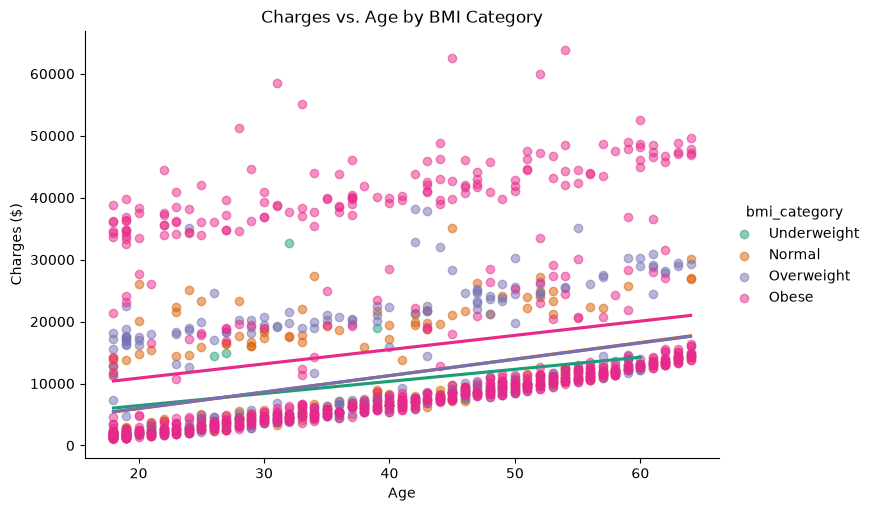

In [167]:
sns.lmplot(
    data=df,
    x='age',
    y='charges',
    hue='bmi_category',
    height=5,
    aspect=1.5,
    palette='Dark2',  
    scatter_kws={'alpha': 0.5},
    ci=None,
)
plt.title('Charges vs. Age by BMI Category')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.show()

**Explanation:** : People with a higher BMI especially in the obese category start with higher pretty much double the medical costs and see their bills climb faster as they get older.

## 16. Create a multiple regression model to predict charges (Dummy Encode and Rescale)

In [168]:
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

X_encoded = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

mult_reg = LinearRegression()
mult_reg.fit(X_scaled, y)

print(X_scaled_df.head())

        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.438764 -0.453320 -0.908614 -1.010519    1.970587         -0.566418   
1 -1.509965  0.509621 -0.078767  0.989591   -0.507463         -0.566418   
2 -0.797954  0.383307  1.580926  0.989591   -0.507463         -0.566418   
3 -0.441948 -1.305531 -0.908614  0.989591   -0.507463          1.765481   
4 -0.513149 -0.292556 -0.908614  0.989591   -0.507463          1.765481   

   region_southeast  region_southwest  
0         -0.611324          1.765481  
1          1.635795         -0.566418  
2          1.635795         -0.566418  
3         -0.611324         -0.566418  
4         -0.611324         -0.566418  


**Explanation:** Text categories (like sex, smoker status, and region) were converted into numbers, and all features were rescaled so the model can compare them equally.

## 17. Make predictions with your multiple regression model and evaluate how well your model is working.

R2: 0.78
RMSE: $5796.28


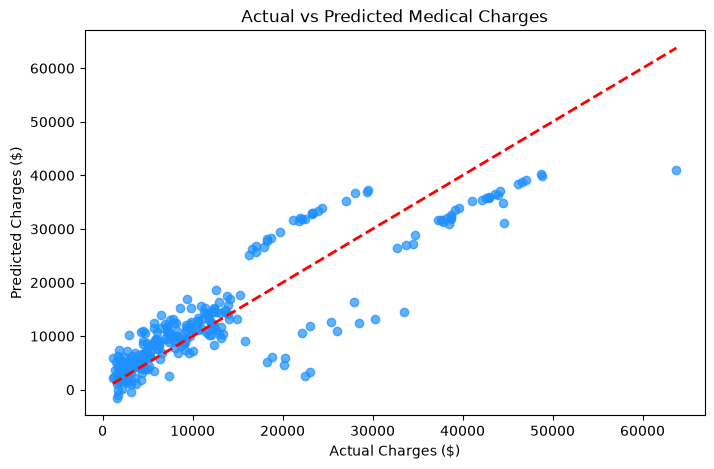

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R2: {r2:.2f}')
print(f'RMSE: ${rmse:.2f}')

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Medical Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.show()

**Explanation:** The model catches about 78% of what drives the costs (like smoking and BMI), meaning it misses the other 22% due to other unpredictable factors, its dollar predictions are off by rougly $5,796 which is not too bad.

## 18. What is the optimal number of parameters for the multiple regression?

In [170]:
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', direction='forward', cv=5)
sfs.fit(X_scaled, y)

selected_features = X_encoded.columns[sfs.get_support()]
for feat in selected_features:
    print(f"{feat}")

print(f"Total optimal number of parameters: {len(selected_features)}")

age
bmi
children
smoker_yes
Total optimal number of parameters: 4


**Explanation:** Using sequential feature selection with cross-validation to test the optimal subset of parameters, the 4 most optimal parameters are age, BMI, number of children, and smoking status, as these are the key indicators used to predict costs.